In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import fmmax
from fmmax import basis, fmm, scattering, utils, fields

print("JAX", jax.__version__, "| fmmax", fmmax.__version__, "|", jax.devices())

def load_cxro(material):
    path = f'/Users/yeshudanbora/euv-rcwa-inverse/data/cxro/{material.lower()}.txt'
    d = np.loadtxt(path, skiprows=2)
    return d[:, 0], d[:, 1], d[:, 2]

def get_n(material, wavelength_nm):
    wl, delta, beta = load_cxro(material)
    return 1 - np.interp(wavelength_nm, wl, delta) + 1j*np.interp(wavelength_nm, wl, beta)


def rcwa_reflectance(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    absorber_thickness_nm=50.0,
    absorber_material='Cr',
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=4.0,
    approximate_num_terms=50,
    uniform_fast_path=True,
):
    """Zeroth-order reflectance from a patterned absorber on Mo/Si multilayer.
    uniform_fast_path=True passes uniform layers as (1,1) arrays, letting fmmax
    use its analytic uniform-media eigensolve instead of the full FFT path."""
    n_air = 1.0 + 0.0j
    n_abs = get_n(absorber_material, wavelength_nm)
    n_mo  = get_n('Mo', wavelength_nm)
    n_si  = get_n('Si', wavelength_nm)
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_abs = jnp.asarray(n_abs**2, dtype=jnp.complex64)
    eps_mo  = jnp.asarray(n_mo**2,  dtype=jnp.complex64)
    eps_si  = jnp.asarray(n_si**2,  dtype=jnp.complex64)

    nx = int(pitch_nm / resolution_nm)
    x_center = pitch_nm / 2.0
    plv = basis.LatticeVectors(u=jnp.asarray([pitch_nm, 0.0]),
                               v=jnp.asarray([0.0, pitch_nm]))
    xg, _ = basis.unit_cell_coordinates(primitive_lattice_vectors=plv, shape=(nx, nx))
    density = (jnp.abs(xg - x_center) <= line_width_nm / 2).astype(jnp.float32)
    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_abs, permittivity_void=eps_air, density=density)

    if uniform_fast_path:
        def uniform(e):
            return jnp.asarray([[e]])
    else:
        def uniform(e):
            return jnp.ones((nx, nx), dtype=jnp.complex64) * e

    permittivities = [uniform(eps_air), eps_grating]
    thicknesses    = [jnp.asarray(0.0), jnp.asarray(absorber_thickness_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si));     thicknesses.append(jnp.asarray(0.0))

    k0 = 2 * jnp.pi / wavelength_nm
    in_plane_wavevector = jnp.asarray([k0 * jnp.sin(jnp.deg2rad(angle_deg)), 0.0])
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=plv,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR)

    lsr = [fmm.eigensolve_isotropic_media(
                wavelength=jnp.asarray(wavelength_nm),
                in_plane_wavevector=in_plane_wavevector,
                primitive_lattice_vectors=plv,
                permittivity=p, expansion=expansion,
                formulation=fmm.Formulation.FFT)
           for p in permittivities]

    s = scattering.stack_s_matrix(layer_solve_results=lsr,
                                  layer_thicknesses=thicknesses)
    n = expansion.num_terms
    return float(jnp.abs(s.s21[0, 0])**2), float(jnp.abs(s.s21[n, n])**2), n


# --- timing + agreement check ---
print("\nWarming up JIT...")
rcwa_reflectance(uniform_fast_path=True)
rcwa_reflectance(uniform_fast_path=False)

print(f"\n{'path':>10}  {'R_TE':>8}  {'R_TM':>8}  {'time (s)':>9}")
print("-" * 40)
for fast in [False, True]:
    t0 = time.time()
    R_te, R_tm, nt = rcwa_reflectance(uniform_fast_path=fast)
    dt = time.time() - t0
    print(f"{'fast' if fast else 'slow':>10}  {R_te:>8.4f}  {R_tm:>8.4f}  {dt:>9.2f}")

JAX 0.10.2 | fmmax v1.7.1 | [CpuDevice(id=0)]

Warming up JIT...

      path      R_TE      R_TM   time (s)
----------------------------------------
      slow    0.1123    0.1632       1.00
      fast    0.2332    0.2309       0.62


In [2]:
print(f"{'N_req':>6}  {'N_act':>6}  {'R_slow':>9}  {'R_fast':>9}  {'Δ':>9}  {'t_slow':>7}  {'t_fast':>7}")
print("-" * 62)
for nf in [25, 50, 100, 200, 400]:
    t0 = time.time()
    R_s, _, nt = rcwa_reflectance(approximate_num_terms=nf, uniform_fast_path=False)
    ts = time.time() - t0
    t0 = time.time()
    R_f, _, _  = rcwa_reflectance(approximate_num_terms=nf, uniform_fast_path=True)
    tf = time.time() - t0
    print(f"{nf:>6}  {nt:>6}  {R_s:>9.4f}  {R_f:>9.4f}  {R_s-R_f:>+9.4f}  {ts:>7.2f}  {tf:>7.2f}")

 N_req   N_act     R_slow     R_fast          Δ   t_slow   t_fast
--------------------------------------------------------------
    25      21     0.2471     0.2471    +0.0000     2.22     0.89
    50      45     0.1123     0.2332    -0.1208     1.33     0.94
   100      97     0.2192     0.2615    -0.0423     3.08     1.17
   200     193     1.2635     0.2638    +0.9998     9.92     2.73
   400     401   609.3106     0.2694  +609.0412    49.78    11.78


In [3]:
print(f"{'N_req':>6}  {'N_act':>6}  {'R_TE':>9}  {'ΔR vs prev':>11}  {'t (s)':>7}")
print("-" * 48)
prev = None
for nf in [100, 200, 300, 400, 600]:
    t0 = time.time()
    R, _, nt = rcwa_reflectance(approximate_num_terms=nf, uniform_fast_path=True)
    dt = time.time() - t0
    d = f"{R-prev:+.5f}" if prev is not None else "—"
    print(f"{nf:>6}  {nt:>6}  {R:>9.5f}  {d:>11}  {dt:>7.2f}")
    prev = R

 N_req   N_act       R_TE   ΔR vs prev    t (s)
------------------------------------------------
   100      97    0.26154            —     1.36
   200     193    0.26379     +0.00226     2.60
   300     293    0.26502     +0.00123     7.05
   400     401    0.26942     +0.00441    12.63
   600     593    0.27015     +0.00073    38.34


In [4]:
print(f"\n{'res (nm)':>9}  {'nx':>5}  {'R_TE':>9}  {'t (s)':>7}")
print("-" * 34)
for res in [8.0, 4.0, 2.0, 1.0]:
    t0 = time.time()
    R, _, nt = rcwa_reflectance(resolution_nm=res, approximate_num_terms=300,
                                uniform_fast_path=True)
    dt = time.time() - t0
    print(f"{res:>9.1f}  {int(840/res):>5}  {R:>9.5f}  {dt:>7.2f}")


 res (nm)     nx       R_TE    t (s)
----------------------------------
      8.0    105    0.26531     5.91
      4.0    210    0.26502     6.20
      2.0    420    0.26496     6.69
      1.0    840    0.26493     6.15


In [6]:
import jax
import jax.numpy as jnp
from functools import partial

# Precompute optical constants at 13.5 nm as plain complex numbers.
# get_n() uses np.interp, which is not JAX-traceable — so we freeze them here.
WL_NM = 13.5
EPS = {m: complex(get_n(m, WL_NM))**2 for m in ['Cr', 'Mo', 'Si', 'Ru', 'TaBN']}
EPS['air'] = 1.0 + 0.0j
print("Permittivities at 13.5 nm:")
for k, v in EPS.items():
    print(f"  {k:>5}: {v.real:+.5f}{v.imag:+.5f}j")


def soft_mask(x, center, half_width, tau):
    """Smooth rectangle: ~1 inside, ~0 outside, sigmoid transition of width ~tau.
    Differentiable w.r.t. half_width (unlike a boolean comparison)."""
    return jax.nn.sigmoid((half_width - jnp.abs(x - center)) / tau)


def rcwa_forward(
    params,                       # jnp array: [cd_nm, sidewall_deg, t_abs_nm, t_arc_nm]
    pitch_nm=840.0,
    angle_deg=6.0,
    resolution_nm=4.0,
    num_terms=200,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    n_slices=8,                   # absorber sub-layers for sidewall
    tau_nm=1.5,                   # edge softness
    absorber='Cr',
    arc='TaBN',
    wavelength_nm=WL_NM,
):
    """Differentiable zeroth-order reflectance.

    params:
      cd_nm         line width at mask scale, at the absorber BASE
      sidewall_deg  90 = vertical; <90 = sloped (narrower at top)
      t_abs_nm      absorber thickness
      t_arc_nm      ARC thickness on top of absorber (same lateral profile)
    """
    cd, sidewall, t_abs, t_arc = params

    eps_air = jnp.asarray(EPS['air'], dtype=jnp.complex64)
    eps_abs = jnp.asarray(EPS[absorber], dtype=jnp.complex64)
    eps_arc = jnp.asarray(EPS[arc], dtype=jnp.complex64)
    eps_mo  = jnp.asarray(EPS['Mo'], dtype=jnp.complex64)
    eps_si  = jnp.asarray(EPS['Si'], dtype=jnp.complex64)

    nx = int(pitch_nm / resolution_nm)
    x_center = pitch_nm / 2.0
    plv = basis.LatticeVectors(u=jnp.asarray([pitch_nm, 0.0]),
                               v=jnp.asarray([0.0, pitch_nm]))
    xg, _ = basis.unit_cell_coordinates(primitive_lattice_vectors=plv, shape=(nx, nx))

    # Lateral inset per unit height for a sloped sidewall.
    # sidewall = 90 deg -> inset 0; smaller angle -> more inset going up.
    inset_per_nm = jnp.tan(jnp.deg2rad(90.0 - sidewall))

    def uniform(e):
        return jnp.asarray([[e]])

    permittivities = [uniform(eps_air)]
    thicknesses    = [jnp.asarray(0.0)]

    # --- ARC on top (narrowest part of the profile) ---
    t_slice_arc = t_arc / n_slices
    for i in range(n_slices):
        z_mid = t_abs + (i + 0.5) * t_slice_arc          # height above absorber base
        hw = jnp.maximum(cd / 2.0 - inset_per_nm * z_mid, 1.0)
        d = soft_mask(xg, x_center, hw, tau_nm)
        permittivities.append(
            utils.interpolate_permittivity(permittivity_solid=eps_arc,
                                           permittivity_void=eps_air,
                                           density=d))
        thicknesses.append(t_slice_arc)

    # --- Absorber, sliced bottom-to-top ---
    t_slice_abs = t_abs / n_slices
    for i in reversed(range(n_slices)):
        z_mid = (i + 0.5) * t_slice_abs
        hw = jnp.maximum(cd / 2.0 - inset_per_nm * z_mid, 1.0)
        d = soft_mask(xg, x_center, hw, tau_nm)
        permittivities.append(
            utils.interpolate_permittivity(permittivity_solid=eps_abs,
                                           permittivity_void=eps_air,
                                           density=d))
        thicknesses.append(t_slice_abs)

    # --- Mo/Si multilayer + substrate ---
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si));     thicknesses.append(jnp.asarray(0.0))

    k0 = 2 * jnp.pi / wavelength_nm
    in_plane_wavevector = jnp.asarray([k0 * jnp.sin(jnp.deg2rad(angle_deg)), 0.0])
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=plv,
        approximate_num_terms=num_terms,
        truncation=basis.Truncation.CIRCULAR)

    lsr = [fmm.eigensolve_isotropic_media(
                wavelength=jnp.asarray(wavelength_nm),
                in_plane_wavevector=in_plane_wavevector,
                primitive_lattice_vectors=plv,
                permittivity=p, expansion=expansion,
                formulation=fmm.Formulation.FFT)
           for p in permittivities]

    s = scattering.stack_s_matrix(layer_solve_results=lsr,
                                  layer_thicknesses=[jnp.asarray(t) for t in thicknesses])
    return jnp.abs(s.s21[0, 0])**2        # no float() — must stay traceable


# --- Smoke test: does it run, and is it near the hard-edge result? ---
p0 = jnp.array([280.0, 90.0, 50.0, 0.001])   # ARC ~0 to compare against Week 2
t0 = time.time()
R0 = rcwa_forward(p0)
print(f"\nSoft-edge model:  R = {float(R0):.5f}   ({time.time()-t0:.1f} s)")

R_hard, _, _ = rcwa_reflectance(approximate_num_terms=200, resolution_nm=4.0,
                                uniform_fast_path=True)
print(f"Hard-edge model:  R = {R_hard:.5f}")
print(f"Difference:       {float(R0) - R_hard:+.5f}")

Permittivities at 13.5 nm:
     Cr: +0.85349+0.08082j
     Mo: +0.85335+0.01189j
     Si: +0.99800+0.00365j
     Ru: +0.78534+0.03025j
   TaBN: +0.86092+0.07071j
    air: +1.00000+0.00000j

Soft-edge model:  R = 0.26315   (5.0 s)
Hard-edge model:  R = 0.26379
Difference:       -0.00064


In [7]:
# Analytic gradients via reverse-mode autodiff
grad_fn = jax.grad(rcwa_forward)

print("Computing analytic gradient (first call compiles, ~1-2 min)...")
t0 = time.time()
g_analytic = grad_fn(p0)
print(f"  done in {time.time()-t0:.1f} s\n")

names = ['CD (nm)', 'sidewall (deg)', 't_abs (nm)', 't_arc (nm)']
print("Analytic gradients dR/dp:")
for nm, g in zip(names, g_analytic):
    print(f"  {nm:>15}: {float(g):+.6e}")

Computing analytic gradient (first call compiles, ~1-2 min)...
  done in 12.4 s

Analytic gradients dR/dp:
          CD (nm): -1.055636e-03
   sidewall (deg): -9.185608e-04
       t_abs (nm): -1.087305e-02
       t_arc (nm): -1.041700e-02


In [8]:
def finite_diff(f, p, idx, h):
    pp = p.at[idx].add(h)
    pm = p.at[idx].add(-h)
    return (f(pp) - f(pm)) / (2 * h)

steps = [2.0, 1.0, 1.0, 1.0]   # nm, deg, nm, nm

print(f"\n{'parameter':>15}  {'analytic':>13}  {'finite diff':>13}  {'rel. err':>9}")
print("-" * 58)
for i, (nm, h) in enumerate(zip(names, steps)):
    t0 = time.time()
    g_fd = finite_diff(rcwa_forward, p0, i, h)
    ga = float(g_analytic[i])
    gf = float(g_fd)
    rel = abs(ga - gf) / max(abs(gf), 1e-12)
    print(f"{nm:>15}  {ga:>+13.5e}  {gf:>+13.5e}  {rel:>9.2%}   ({time.time()-t0:.0f}s)")


      parameter       analytic    finite diff   rel. err
----------------------------------------------------------
        CD (nm)   -1.05564e-03   -1.05979e-03      0.39%   (10s)
 sidewall (deg)   -9.18561e-04   -9.21175e-04      0.28%   (8s)
     t_abs (nm)   -1.08731e-02   -9.15444e-03     18.77%   (7s)
     t_arc (nm)   -1.04170e-02   -8.78622e-03     18.56%   (7s)


In [9]:
print(f"{'h (nm)':>8}  {'FD t_abs':>14}  {'rel err':>9}  {'FD t_arc':>14}  {'rel err':>9}")
print("-" * 62)
ga_abs, ga_arc = float(g_analytic[2]), float(g_analytic[3])
for h in [1.0, 0.5, 0.2, 0.1, 0.05]:
    f_abs = float(finite_diff(rcwa_forward, p0, 2, h))
    f_arc = float(finite_diff(rcwa_forward, p0, 3, h))
    e_abs = abs(ga_abs - f_abs) / abs(f_abs)
    e_arc = abs(ga_arc - f_arc) / abs(f_arc)
    print(f"{h:>8.2f}  {f_abs:>+14.5e}  {e_abs:>9.2%}  {f_arc:>+14.5e}  {e_arc:>9.2%}")

  h (nm)        FD t_abs    rel err        FD t_arc    rel err
--------------------------------------------------------------
    1.00    -9.15444e-03     18.77%    -8.78622e-03     18.56%
    0.50    -1.04297e-02      4.25%    -9.99558e-03      4.22%
    0.20    -1.08033e-02      0.65%    -1.03495e-02      0.65%
    0.10    -1.08540e-02      0.18%    -1.04007e-02      0.16%
    0.05    -1.08632e-02      0.09%    -1.04094e-02      0.07%


In [10]:
p_arc = jnp.array([280.0, 90.0, 50.0, 14.0])   # realistic 14 nm ARC
g_arc = grad_fn(p_arc)
print(f"\nAt t_arc = 14 nm:")
for h in [1.0, 0.5, 0.2]:
    fd = float(finite_diff(rcwa_forward, p_arc, 3, h))
    print(f"  h={h:>4.1f}:  analytic {float(g_arc[3]):+.5e}   FD {fd:+.5e}   "
          f"err {abs(float(g_arc[3])-fd)/abs(fd):.2%}")


At t_arc = 14 nm:
  h= 1.0:  analytic -7.29972e-03   FD -6.12859e-03   err 19.11%
  h= 0.5:  analytic -7.29972e-03   FD -6.99767e-03   err 4.32%
  h= 0.2:  analytic -7.29972e-03   FD -7.25009e-03   err 0.68%


In [11]:
# --- JAX-traceable optical constants ---
MATERIALS = ['Cr', 'Mo', 'Si', 'Ru', 'TaBN']
_wl_ref, _, _ = load_cxro('Mo')
WL_TABLE = jnp.asarray(_wl_ref)

EPS_TABLE = {}
for m in MATERIALS:
    wl, delta, beta = load_cxro(m)
    n = (1 - delta) + 1j*beta
    EPS_TABLE[m] = jnp.asarray(n**2, dtype=jnp.complex64)

def eps_at(material, wavelength_nm):
    """Traceable permittivity lookup — interpolates real and imag separately."""
    tbl = EPS_TABLE[material]
    re = jnp.interp(wavelength_nm, WL_TABLE, tbl.real)
    im = jnp.interp(wavelength_nm, WL_TABLE, tbl.imag)
    return (re + 1j*im).astype(jnp.complex64)

# check against the frozen dict
for m in ['Cr', 'Mo', 'Si']:
    a = complex(eps_at(m, 13.5))
    b = EPS[m]
    print(f"  {m:>5}: traceable {a.real:+.5f}{a.imag:+.5f}j | frozen {b.real:+.5f}{b.imag:+.5f}j")

     Cr: traceable +0.85349+0.08082j | frozen +0.85349+0.08082j
     Mo: traceable +0.85335+0.01189j | frozen +0.85335+0.01189j
     Si: traceable +0.99800+0.00365j | frozen +0.99800+0.00365j


In [14]:
# --- Precompute static geometry ONCE, outside any traced function ---
PITCH_NM = 840.0
RES_NM = 4.0
NUM_TERMS = 200
NX = int(PITCH_NM / RES_NM)
X_CENTER = PITCH_NM / 2.0

PLV = basis.LatticeVectors(u=jnp.asarray([PITCH_NM, 0.0]),
                           v=jnp.asarray([0.0, PITCH_NM]))
XG, _ = basis.unit_cell_coordinates(primitive_lattice_vectors=PLV, shape=(NX, NX))
EXPANSION = basis.generate_expansion(
    primitive_lattice_vectors=PLV,
    approximate_num_terms=NUM_TERMS,
    truncation=basis.Truncation.CIRCULAR)

print(f"Static geometry: nx={NX}, num_terms={EXPANSION.num_terms}")


def rcwa_forward_wl(
    params, wavelength_nm,
    angle_deg=6.0, n_bilayers=40, d_mo_nm=2.78, d_si_nm=4.17,
    n_slices=8, tau_nm=1.5, absorber='Cr', arc='TaBN',
):
    """Zeroth-order reflectance at one wavelength. Fully traceable."""
    cd, sidewall, t_abs, t_arc = params

    eps_air = jnp.asarray(1.0 + 0.0j, dtype=jnp.complex64)
    eps_abs = eps_at(absorber, wavelength_nm)
    eps_arc = eps_at(arc, wavelength_nm)
    eps_mo  = eps_at('Mo', wavelength_nm)
    eps_si  = eps_at('Si', wavelength_nm)

    inset_per_nm = jnp.tan(jnp.deg2rad(90.0 - sidewall))

    def uniform(e):
        return jnp.asarray([[e]])

    permittivities = [uniform(eps_air)]
    thicknesses    = [jnp.asarray(0.0)]

    t_slice_arc = t_arc / n_slices
    for i in range(n_slices):
        z_mid = t_abs + (i + 0.5) * t_slice_arc
        hw = jnp.maximum(cd/2.0 - inset_per_nm*z_mid, 1.0)
        d = soft_mask(XG, X_CENTER, hw, tau_nm)
        permittivities.append(utils.interpolate_permittivity(
            permittivity_solid=eps_arc, permittivity_void=eps_air, density=d))
        thicknesses.append(t_slice_arc)

    t_slice_abs = t_abs / n_slices
    for i in reversed(range(n_slices)):
        z_mid = (i + 0.5) * t_slice_abs
        hw = jnp.maximum(cd/2.0 - inset_per_nm*z_mid, 1.0)
        d = soft_mask(XG, X_CENTER, hw, tau_nm)
        permittivities.append(utils.interpolate_permittivity(
            permittivity_solid=eps_abs, permittivity_void=eps_air, density=d))
        thicknesses.append(t_slice_abs)

    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si));     thicknesses.append(jnp.asarray(0.0))

    k0 = 2*jnp.pi / wavelength_nm
    in_plane_wavevector = jnp.asarray([k0*jnp.sin(jnp.deg2rad(angle_deg)), 0.0])

    lsr = [fmm.eigensolve_isotropic_media(
                wavelength=jnp.asarray(wavelength_nm),
                in_plane_wavevector=in_plane_wavevector,
                primitive_lattice_vectors=PLV,
                permittivity=p, expansion=EXPANSION,
                formulation=fmm.Formulation.FFT)
           for p in permittivities]

    s = scattering.stack_s_matrix(layer_solve_results=lsr,
                                  layer_thicknesses=[jnp.asarray(t) for t in thicknesses])
    return jnp.abs(s.s21[0, 0])**2


# consistency check
p_test = jnp.array([280.0, 90.0, 50.0, 14.0])
print(f"single wl @13.5: {float(rcwa_forward_wl(p_test, 13.5)):.5f}")

Static geometry: nx=210, num_terms=193
single wl @13.5: 0.27919


Compiling batched spectrum (this may take several minutes)...
  first call:  65.9 s
  cached call: 58.40 s  (1424 ms/wavelength)


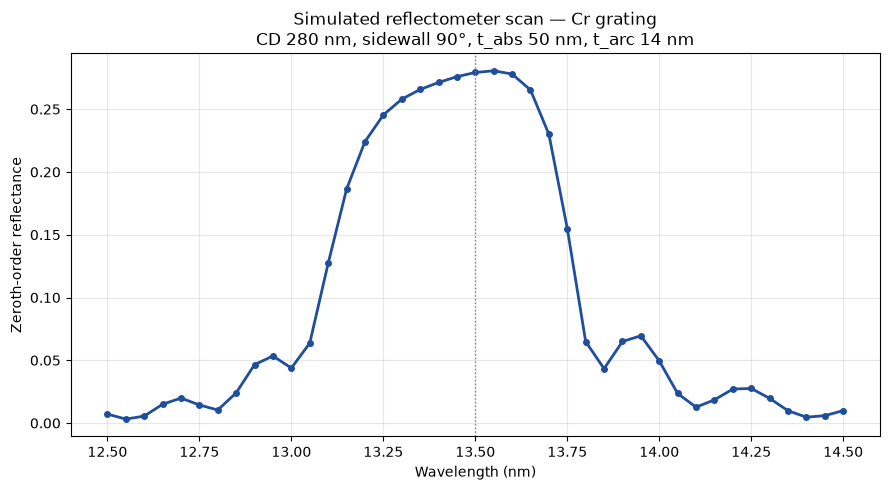

In [15]:
N_WL = 41
WL_GRID = jnp.linspace(12.5, 14.5, N_WL)

spectrum_fn = jax.jit(jax.vmap(rcwa_forward_wl, in_axes=(None, 0)))

print("Compiling batched spectrum (this may take several minutes)...")
t0 = time.time()
R_spec = spectrum_fn(p_test, WL_GRID)
R_spec.block_until_ready()
print(f"  first call:  {time.time()-t0:.1f} s")

t0 = time.time()
R2 = spectrum_fn(p_test, WL_GRID); R2.block_until_ready()
dt = time.time()-t0
print(f"  cached call: {dt:.2f} s  ({dt/N_WL*1000:.0f} ms/wavelength)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.array(WL_GRID), np.array(R_spec), 'o-', color='#1f4e9c', lw=2, ms=4)
ax.axvline(13.5, color='0.5', ls=':', lw=1)
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Zeroth-order reflectance')
ax.set_title('Simulated reflectometer scan — Cr grating\nCD 280 nm, sidewall 90°, t_abs 50 nm, t_arc 14 nm')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [16]:
def make_spectrum_fn(num_terms, n_wl, wl_min=13.0, wl_max=14.0):
    """Build a jitted spectrum function at a given truncation and wavelength count."""
    global EXPANSION
    EXPANSION = basis.generate_expansion(
        primitive_lattice_vectors=PLV,
        approximate_num_terms=num_terms,
        truncation=basis.Truncation.CIRCULAR)
    wl = jnp.linspace(wl_min, wl_max, n_wl)
    fn = jax.jit(jax.vmap(rcwa_forward_wl, in_axes=(None, 0)))
    return fn, wl, EXPANSION.num_terms

print(f"{'N_terms':>8}  {'n_wl':>5}  {'actual N':>9}  {'compile':>9}  {'cached':>8}  {'R@peak':>8}")
print("-" * 58)
for nt_req, n_wl in [(100, 15), (100, 21), (200, 15), (200, 21)]:
    fn, wl, nt_act = make_spectrum_fn(nt_req, n_wl)
    t0 = time.time(); R = fn(p_test, wl); R.block_until_ready(); t_c = time.time()-t0
    t0 = time.time(); R = fn(p_test, wl); R.block_until_ready(); t_r = time.time()-t0
    print(f"{nt_req:>8}  {n_wl:>5}  {nt_act:>9}  {t_c:>8.1f}s  {t_r:>7.1f}s  {float(R.max()):>8.4f}")

 N_terms   n_wl   actual N    compile    cached    R@peak
----------------------------------------------------------
     100     15         97       8.3s      3.6s    0.2765
     100     21         97       8.0s      4.9s    0.2767
     200     15        193      24.6s     21.7s    0.2801
     200     21        193      33.8s     30.2s    0.2806


In [18]:
# Lock fitting configuration
EXPANSION = basis.generate_expansion(
    primitive_lattice_vectors=PLV,
    approximate_num_terms=100,
    truncation=basis.Truncation.CIRCULAR)
WL_FIT = jnp.linspace(13.0, 14.0, 15)
spectrum = jax.jit(jax.vmap(rcwa_forward_wl, in_axes=(None, 0)))

print(f"Fitting config: N={EXPANSION.num_terms}, {len(WL_FIT)} wavelengths")

# Ground truth and its spectrum
P_TRUE = jnp.array([280.0, 88.0, 50.0, 14.0])   # CD, sidewall, t_abs, t_arc
R_true = spectrum(P_TRUE, WL_FIT)
print(f"R range: [{float(R_true.min()):.4f}, {float(R_true.max()):.4f}]")

# Jacobian: dR_i / dp_j  -> shape (n_wl, 4)
print("\nComputing Jacobian (reverse mode)...")
t0 = time.time()
J = jax.jacrev(lambda p: spectrum(p, WL_FIT))(P_TRUE)
J = np.array(J)
print(f"  {J.shape} in {time.time()-t0:.1f} s")

NAMES = ['CD (nm)', 'sidewall (deg)', 't_abs (nm)', 't_arc (nm)']
print(f"\n{'parameter':>15}  {'‖dR/dp‖':>12}  {'max |dR/dp|':>12}")
print("-" * 44)
for j, nm in enumerate(NAMES):
    print(f"{nm:>15}  {np.linalg.norm(J[:, j]):>12.3e}  {np.abs(J[:, j]).max():>12.3e}")

# Conditioning
U, S, Vt = np.linalg.svd(J, full_matrices=False)
print(f"\nSingular values: {S}")
print(f"Condition number: {S[0]/S[-1]:.1f}")

print("\nRight singular vectors (which parameter combinations are well/poorly constrained):")
for k in range(len(S)):
    combo = "  ".join(f"{nm.split()[0]}:{Vt[k, j]:+.2f}" for j, nm in enumerate(NAMES))
    print(f"  σ={S[k]:.3e}  |  {combo}")

# Noise-limited uncertainty at 0.5% relative noise
sigma = 0.005 * float(R_true.mean())
cov = np.linalg.inv(J.T @ J) * sigma**2
print(f"\nExpected 1σ uncertainty (noise = {sigma:.5f}):")
for j, nm in enumerate(NAMES):
    print(f"  {nm:>15}: ±{np.sqrt(cov[j, j]):.3f}")

Fitting config: N=97, 15 wavelengths
R range: [0.0425, 0.2796]

Computing Jacobian (reverse mode)...
  (15, 4) in 122.7 s

      parameter       ‖dR/dp‖   max |dR/dp|
--------------------------------------------
        CD (nm)     3.648e-03     1.382e-03
 sidewall (deg)     4.251e-03     1.622e-03
     t_abs (nm)     3.032e-02     1.364e-02
     t_arc (nm)     2.913e-02     1.289e-02

Singular values: [4.2032003e-02 5.6245741e-03 7.4225169e-04 1.7548005e-05]
Condition number: 2395.3

Right singular vectors (which parameter combinations are well/poorly constrained):
  σ=4.203e-02  |  CD:+0.00  sidewall:+0.00  t_abs:-0.72  t_arc:-0.69
  σ=5.625e-03  |  CD:+0.65  sidewall:+0.75  t_abs:-0.07  t_arc:+0.08
  σ=7.423e-04  |  CD:-0.09  sidewall:-0.05  t_abs:-0.69  t_arc:+0.72
  σ=1.755e-05  |  CD:+0.76  sidewall:-0.65  t_abs:-0.03  t_arc:+0.03

Expected 1σ uncertainty (noise = 0.00087):
          CD (nm): ±37.635
   sidewall (deg): ±32.554
       t_abs (nm): ±1.539
       t_arc (nm): ±1.545


In [21]:
import optax

# Fix the ill-conditioned parameters at their true values; fit only thicknesses.
CD_FIXED = 280.0
SIDEWALL_FIXED = 88.0
P_TRUE_2 = jnp.array([50.0, 14.0])          # [t_abs, t_arc]

def spectrum_2p(p2, wl):
    """Spectrum as a function of the two well-conditioned parameters."""
    full = jnp.array([CD_FIXED, SIDEWALL_FIXED, p2[0], p2[1]])
    return spectrum(full, wl)

# --- Synthetic measurement with realistic reflectometer noise ---
key = jax.random.PRNGKey(0)
R_clean = spectrum_2p(P_TRUE_2, WL_FIT)
NOISE_FRAC = 0.005                          # 0.5% relative, typical tool spec
sigma = NOISE_FRAC * float(jnp.mean(R_clean))
R_meas = R_clean + sigma * jax.random.normal(key, R_clean.shape)

print(f"Ground truth: t_abs={float(P_TRUE_2[0]):.2f} nm, t_arc={float(P_TRUE_2[1]):.2f} nm")
print(f"Noise sigma = {sigma:.6f}  ({NOISE_FRAC*100:.1f}% of mean R)")

# --- Loss and gradient (reverse mode only) ---
def loss_fn(p2):
    return jnp.mean((spectrum_2p(p2, WL_FIT) - R_meas)**2)

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))

# --- Optimize from a deliberately wrong starting point ---
p = jnp.array([38.0, 22.0])                 # 12 nm and 8 nm off
opt = optax.adam(learning_rate=0.8)
state = opt.init(p)

print(f"\nStart: t_abs={float(p[0]):.2f}, t_arc={float(p[1]):.2f}")
print(f"\n{'iter':>5}  {'loss':>12}  {'t_abs':>8}  {'t_arc':>8}  {'|grad|':>10}")
print("-" * 50)

history = []
t_start = time.time()
for i in range(40):
    L, g = loss_and_grad(p)
    updates, state = opt.update(g, state)
    p = optax.apply_updates(p, updates)
    history.append((i, float(L), float(p[0]), float(p[1])))
    if i % 4 == 0 or i == 39:
        print(f"{i:>5}  {float(L):>12.3e}  {float(p[0]):>8.3f}  {float(p[1]):>8.3f}  {float(jnp.linalg.norm(g)):>10.3e}")

print(f"\nElapsed: {time.time()-t_start:.0f} s")
print(f"\nRecovered: t_abs = {float(p[0]):.3f} nm   (true 50.000, error {float(p[0])-50:+.3f})")
print(f"           t_arc = {float(p[1]):.3f} nm   (true 14.000, error {float(p[1])-14:+.3f})")
print(f"Predicted 1σ from Jacobian: ±1.54 nm each")

Ground truth: t_abs=50.00 nm, t_arc=14.00 nm
Noise sigma = 0.000871  (0.5% of mean R)

Start: t_abs=38.00, t_arc=22.00

 iter          loss     t_abs     t_arc      |grad|
--------------------------------------------------
    0     2.468e-04    37.200    21.200   9.212e-05
    4     1.153e-04    36.369    20.259   1.130e-04
    8     9.106e-05    37.240    20.949   9.468e-05
   12     6.321e-05    36.649    20.129   3.176e-05
   16     6.348e-05    37.062    20.284   3.595e-05
   20     6.811e-05    37.380    20.309   5.504e-05
   24     6.149e-05    37.185    19.788   3.387e-05
   28     5.718e-05    37.621    19.884   3.541e-06
   32     5.776e-05    37.747    19.642   2.230e-05
   36     5.737e-05    37.834    19.347   2.544e-05
   39     5.497e-05    38.129    19.358   7.363e-06

Elapsed: 738 s

Recovered: t_abs = 38.129 nm   (true 50.000, error -11.871)
           t_arc = 19.358 nm   (true 14.000, error +5.358)
Predicted 1σ from Jacobian: ±1.54 nm each


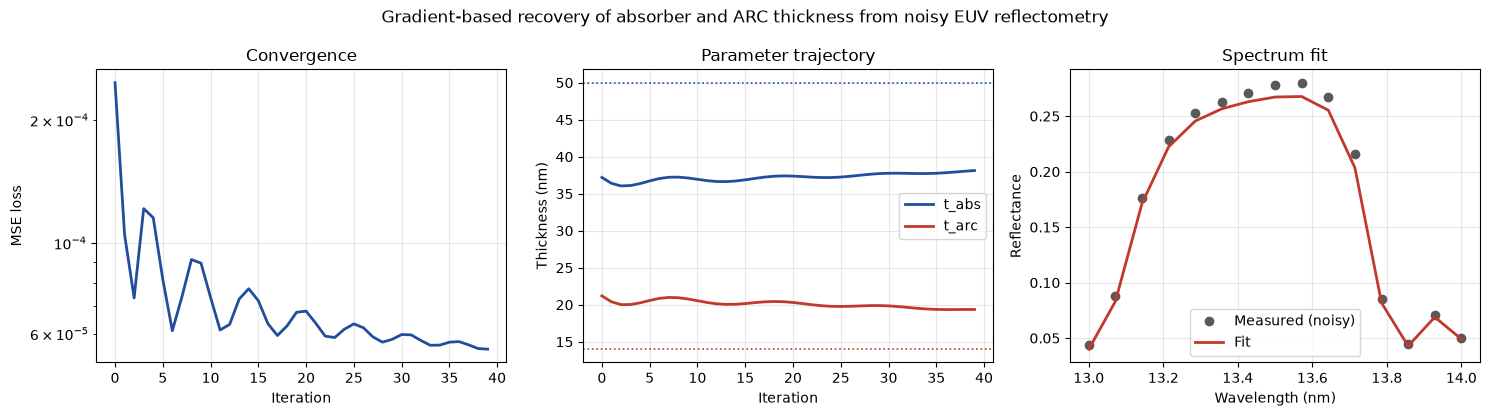

In [22]:
hist = np.array(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].semilogy(hist[:, 0], hist[:, 1], color='#1f4e9c', lw=2)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE loss')
axes[0].set_title('Convergence'); axes[0].grid(alpha=0.3)

axes[1].plot(hist[:, 0], hist[:, 2], color='#1f4e9c', lw=2, label='t_abs')
axes[1].plot(hist[:, 0], hist[:, 3], color='#c0392b', lw=2, label='t_arc')
axes[1].axhline(50, color='#1f4e9c', ls=':', lw=1.2)
axes[1].axhline(14, color='#c0392b', ls=':', lw=1.2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Thickness (nm)')
axes[1].set_title('Parameter trajectory'); axes[1].legend(); axes[1].grid(alpha=0.3)

R_fit = spectrum_2p(p, WL_FIT)
axes[2].plot(np.array(WL_FIT), np.array(R_meas), 'o', color='0.35', ms=6, label='Measured (noisy)')
axes[2].plot(np.array(WL_FIT), np.array(R_fit), '-', color='#c0392b', lw=2, label='Fit')
axes[2].set_xlabel('Wavelength (nm)'); axes[2].set_ylabel('Reflectance')
axes[2].set_title('Spectrum fit'); axes[2].legend(); axes[2].grid(alpha=0.3)

fig.suptitle('Gradient-based recovery of absorber and ARC thickness from noisy EUV reflectometry',
             fontsize=12)
plt.tight_layout()
plt.savefig('/Users/yeshudanbora/euv-rcwa-inverse/figures/inverse_fit.png',
            dpi=200, bbox_inches='tight')
plt.show()

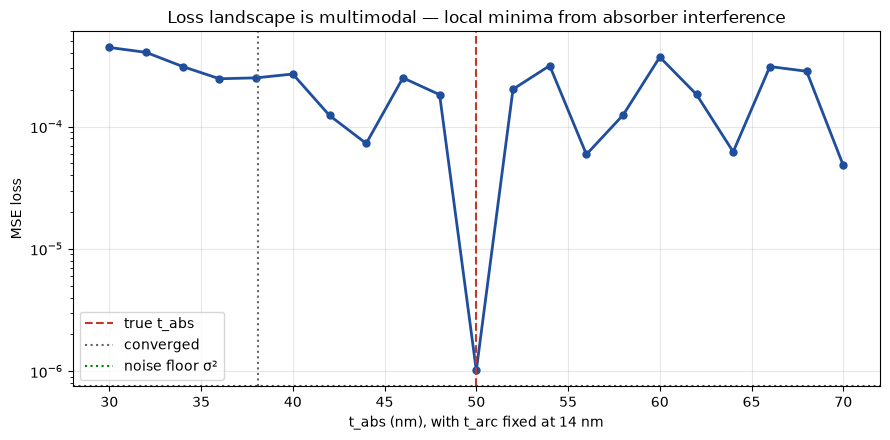

Global min in scan: t_abs = 50.0 nm, loss = 1.015e-06
Noise floor σ²    = 7.580e-07


In [23]:
t_scan = np.arange(30.0, 72.0, 2.0)
losses = []
for t in t_scan:
    losses.append(float(loss_fn(jnp.array([t, 14.0]))))
losses = np.array(losses)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(t_scan, losses, 'o-', color='#1f4e9c', lw=2, ms=5)
ax.axvline(50.0, color='#c0392b', ls='--', lw=1.5, label='true t_abs')
ax.axvline(38.13, color='0.4', ls=':', lw=1.5, label='converged')
ax.axhline(sigma**2, color='green', ls=':', lw=1.5, label='noise floor σ²')
ax.set_xlabel('t_abs (nm), with t_arc fixed at 14 nm')
ax.set_ylabel('MSE loss')
ax.set_title('Loss landscape is multimodal — local minima from absorber interference')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/yeshudanbora/euv-rcwa-inverse/figures/loss_landscape.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"Global min in scan: t_abs = {t_scan[losses.argmin()]:.1f} nm, loss = {losses.min():.3e}")
print(f"Noise floor σ²    = {sigma**2:.3e}")